<a href="https://colab.research.google.com/github/Christi049/Group-fairness-in-IM/blob/main/Group_fairness_in_IM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install gurobi

In [1]:
!pip install -q "gurobipy>=10"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 86.0 MB/s eta 0:00:00


In [2]:
import gurobipy as gp
print(gp.gurobi.version())

(13, 0, 2)


In [3]:
import gurobipy as gp

env = gp.Env()
env.start()

print("Gurobi environment started successfully!")

Restricted license - for non-production use only - expires 2027-11-29
Gurobi environment started successfully!


In [5]:
!grep -n "solver =" /content/fair_influmax_code_release/check_fairness.py

grep: /content/fair_influmax_code_release/check_fairness.py: No such file or directory


In [6]:
!git clone https://github.com/bwilder0/fair_influmax_code_release.git
%cd fair_influmax_code_release

Cloning into 'fair_influmax_code_release'...
remote: Enumerating objects: 57, done.
remote: Total 57 (delta 0), reused 0 (delta 0), pack-reused 57 (from 1)
Receiving objects: 100% (57/57), 979.78 KiB | 5.21 MiB/s, done.
Resolving deltas: 100% (13/13), done.
/content/fair_influmax_code_release


In [7]:
!ls

algorithms.py			  check_fairness.py  networks	utils.py
check_fairness_intersectional.py  icm.py	     README.md


fix old version - change every instance of g.node[v][attribute] to g.nodes[v][attribute]

In [8]:
!grep -rn '\.node\[' /content/fair_influmax_code_release --include=*.py

/content/fair_influmax_code_release/check_fairness_intersectional.py:71:            if 'race' not in g.node[v]:
/content/fair_influmax_code_release/check_fairness_intersectional.py:89:            nvalues = len(np.unique([g.node[v][attribute] for v in g.nodes()]))
/content/fair_influmax_code_release/check_fairness_intersectional.py:92:                    if np.isnan(g.node[v][attribute]):
/content/fair_influmax_code_release/check_fairness_intersectional.py:93:                        g.node[v][attribute] = nvalues
/content/fair_influmax_code_release/check_fairness_intersectional.py:96:                    g.node[v][attribute] = attribute + '_' + str(int(g.node[v][attribute]))
/content/fair_influmax_code_release/check_fairness_intersectional.py:97:            nvalues = len(np.unique([g.node[v][attribute] for v in g.nodes()]))
/content/fair_influmax_code_release/check_fairness_intersectional.py:132:            values = np.unique([g.node[v][attribute] for v in g.nodes()])
/content/fair_influ

In [9]:
!grep -rl '\.node\[' /content/fair_influmax_code_release --include=*.py | xargs sed -i 's/\.node\[/.nodes[/g'

In [10]:
!grep -rn '\.node\[' /content/fair_influmax_code_release --include=*.py

fix old version - change every instance of np.int to int

In [11]:
!grep -rn 'np\.\(int\|float\|bool\|object\)\b' /content/fair_influmax_code_release --include=*.py

/content/fair_influmax_code_release/icm.py:151:        G_array = np.zeros((n, max_degree), dtype=np.int)
/content/fair_influmax_code_release/icm.py:188:        G = np.zeros(g.number_of_edges(), dtype=np.int)
/content/fair_influmax_code_release/icm.py:192:        start_pos = np.zeros(len(g)+1, dtype=np.int)


In [12]:
!grep -rl 'np\.int\b' /content/fair_influmax_code_release --include=*.py | xargs sed -i 's/np\.int\b/int/g'

In [13]:
!grep -rn 'np\.\(int\|float\|bool\|object\)\b' /content/fair_influmax_code_release --include=*.py

In [14]:
!sed -i \
  -e 's/val_oracle(x, 1000)/val_oracle(x, 1000)/' \
  -e 's/val_oracle((1\/num_iter)\*x\[0:t\].sum(axis=0), 5000)/val_oracle((1\/num_iter)*x[0:t].sum(axis=0), 1000)/' \
  -e 's/num_iter=1000/num_iter=500/' \
  -e 's/val_oracle(x.mean(axis=0), 1000)/val_oracle(x.mean(axis=0), 500)/' \
  /content/fair_influmax_code_release/algorithms.py

In [15]:
!grep -n '200\|500' /content/fair_influmax_code_release/algorithms.py

41:def mirror_sp(x, grad_oracle, k, group_indicator, group_targets, num_iter, step_size = 1, batch_size = 200, verbose=False):
80:    g = grad_oracle(x, 5000)
141:            x[t+1] = mirror_sp((1./(t+1))*x[0:(t+1)].sum(axis=0), grad_oracle, k, group_indicator, iter_targets, num_iter=500)
213:        vals = val_oracle(x.mean(axis=0), 500)


In [16]:
!sed -i 's/sample_live_icm(g, 1000)/sample_live_icm(g, 500)/' /content/fair_influmax_code_release/check_fairness.py
!sed -i 's/sample_live_icm(h, 1000)/sample_live_icm(h, 500)/' /content/fair_influmax_code_release/check_fairness.py

!sed -i 's/np.array(targets), 100, solver/np.array(targets), 100, solver/' /content/fair_influmax_code_release/check_fairness.py

!sed -i 's/group_indicator, 20, 10, 0.05, solver/group_indicator, 20, 10, 0.05, solver/' /content/fair_influmax_code_release/check_fairness.py

In [17]:
!sed -i 's/budget = 15/budget = 25/' /content/fair_influmax_code_release/check_fairness.py

In [22]:
!sed -i "s/solver = 'md'/solver = 'gurobi'/" /content/fair_influmax_code_release/check_fairness.py

Reducing the number of networks and attributes

In [23]:
!sed -i \
-e "s/attributes = \['region', 'ethnicity', 'age', 'gender', 'status'\]/attributes = ['region', 'age', 'gender']/" \
-e "s/graphnames = \['spa_500_{}'.format(graphidx) for graphidx in range(10)\]/graphnames = ['spa_500_0', 'spa_500_1', 'spa_500_2']/" \
/content/fair_influmax_code_release/check_fairness.py

In [24]:
!grep -n "solver =" /content/fair_influmax_code_release/check_fairness.py

40:solver = 'gurobi'


with budget = 25

In [25]:
!python check_fairness.py

Budget: 25
['spa_500_0', 'spa_500_1', 'spa_500_2']
spa_500_0 0
Restricted license - for non-production use only - expires 2027-11-29
fair: 0.23417596479330363, greedy: 0.5637615185975429
fair: 0.056613749870228325, greedy: 0.10314174902408531
fair: 0.03464949856845059, greedy: 0.0328230791875184
spa_500_1 0
fair: 0.20642143679467825, greedy: 0.5611045512641305
fair: 0.052616757067446576, greedy: 0.031123936382638516
fair: 0.033495578071454056, greedy: 0.04058446632286311
spa_500_2 0
fair: 0.21459662927594067, greedy: 0.5915080947514747
fair: 0.020706791529261415, greedy: 0.1782468228315485
fair: 0.05418486969220847, greedy: 0.001442531409958284


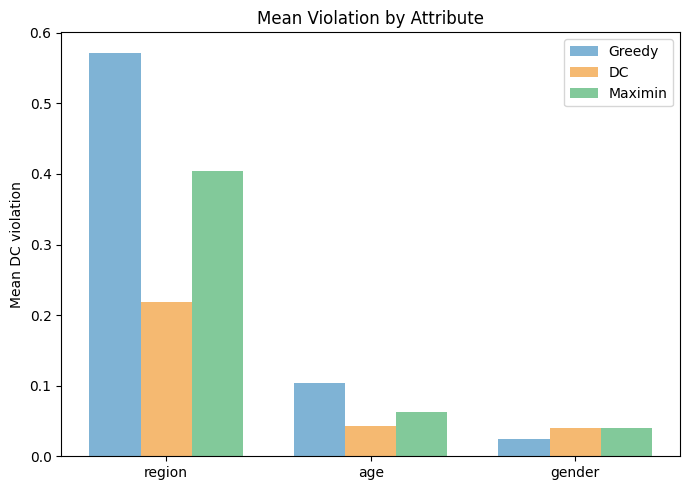

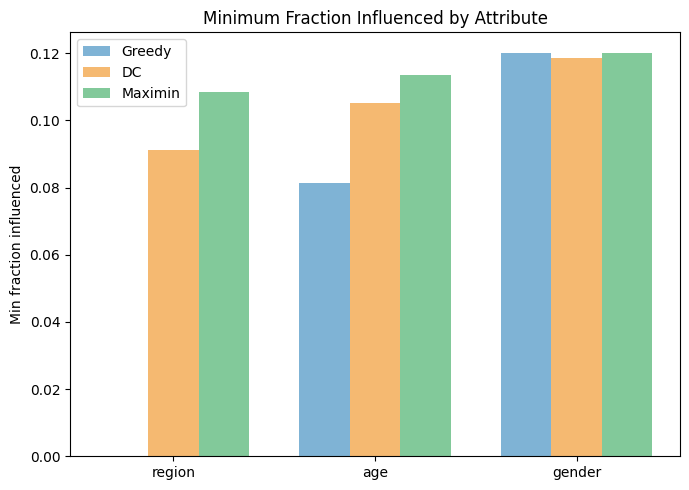

Saved: mean_violation.png, min_fraction.png


In [27]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

# Load your saved results
alg_values, gr_values, group_size = pickle.load(open('/content/fair_influmax_code_release/results_spa.pickle', 'rb'))

graphnames = ['spa_500_0', 'spa_500_1', 'spa_500_2']
attributes = ['region', 'age', 'gender']
algorithms = ['Greedy', 'GR', 'MaxMin-Size']

# --- Compute Metric A: Mean violation, averaged across graphs ---
mean_violation = {alg: [] for alg in algorithms}

for attribute in attributes:
    for alg in algorithms:
        violations_across_graphs = []
        for graphname in graphnames:
            all_opt = gr_values[graphname][attribute][0]  # run 0
            actual_vals = alg_values[alg][graphname][attribute][0]
            violation = np.clip(all_opt - actual_vals, 0, np.inf) / all_opt
            violations_across_graphs.append(violation.mean())
        mean_violation[alg].append(np.mean(violations_across_graphs))

# --- Compute Metric B: Min fraction influenced, averaged across graphs ---
min_fraction = {alg: [] for alg in algorithms}

for attribute in attributes:
    for alg in algorithms:
        min_fracs_across_graphs = []
        for graphname in graphnames:
            actual_vals = alg_values[alg][graphname][attribute][0]
            sizes = group_size[graphname][attribute][0]
            frac = (actual_vals / sizes).min()
            min_fracs_across_graphs.append(frac)
        min_fraction[alg].append(np.mean(min_fracs_across_graphs))

# --- Plot Panel 1: Mean violation ---
x = np.arange(len(attributes))
width = 0.25
colors = {'Greedy': '#7fb3d5', 'GR': '#f5b971', 'MaxMin-Size': '#82c99a'}
labels = {'Greedy': 'Greedy', 'GR': 'DC', 'MaxMin-Size': 'Maximin'}

fig, ax = plt.subplots(figsize=(7, 5))
for i, alg in enumerate(algorithms):
    ax.bar(x + (i-1)*width, mean_violation[alg], width, label=labels[alg], color=colors[alg])
ax.set_xticks(x)
ax.set_xticklabels(attributes)
ax.set_ylabel('Mean DC violation')
ax.set_title('Mean Violation by Attribute')
ax.legend()
plt.tight_layout()
plt.savefig('/content/mean_violation.png', dpi=150)
plt.show()

# --- Plot Panel 2: Min fraction influenced ---
fig, ax = plt.subplots(figsize=(7, 5))
for i, alg in enumerate(algorithms):
    ax.bar(x + (i-1)*width, min_fraction[alg], width, label=labels[alg], color=colors[alg])
ax.set_xticks(x)
ax.set_xticklabels(attributes)
ax.set_ylabel('Min fraction influenced')
ax.set_title('Minimum Fraction Influenced by Attribute')
ax.legend()
plt.tight_layout()
plt.savefig('/content/min_fraction.png', dpi=150)
plt.show()

print("Saved: mean_violation.png, min_fraction.png")